# 00b — Echo Nest Taste Profile: Download, Filtering & Analysis

Links **user listening behaviour** from the Echo Nest Taste Profile to the
Lakh MIDI Dataset (LMD) via the Echo Nest `song_id` stored in each MSD HDF5 file.

**Pipeline**
1. Download `train_triplets.txt.zip` (~500 MB) and `sid_mismatches.txt`
2. Load raw triplets  *(user_id, song_id, play_count)* — ~48 M rows
3. Parse and apply the mismatch exclusion list  (~19 k bad song IDs)
4. Intersect with LMD-matched `song_id` set  (only songs that have a MIDI file)
5. Remove cold-start users  (≥ N interactions required)
6. Before / after comparison table and bar chart
7. Descriptive statistics + four diagnostic plots
8. Save filtered triplets and per-user / per-song summaries to disk

> **Prerequisites**: Run `notebooks/00_dataset_extraction_exploration.ipynb` first
> to produce `data/processed/lakh_msd_dataset.parquet`.


## 1 — Imports & Configuration


In [ ]:
import sys
import pathlib
import subprocess
import warnings
import os

warnings.filterwarnings("ignore")
if str(pathlib.Path(os.getcwd()).name) == 'DL-KG-project':
    os.chdir('notebooks')
sys.path.insert(0, str(pathlib.Path("..").resolve() / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from data.dataset_extraction import (
    load_dataset,
    load_taste_profile,
    load_sid_mismatches,
    filter_taste_profile,
    build_user_song_stats,
)

sns.set_theme(style="whitegrid")
REPO_ROOT = pathlib.Path("..").resolve()

# ── Paths ─────────────────────────────────────────────────────────────────────
RAW_DIR       = REPO_ROOT / "data" / "raw"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TRIPLETS_ZIP  = RAW_DIR / "train_triplets.txt.zip"
TRIPLETS_TXT  = RAW_DIR / "train_triplets.txt"
MISMATCHES    = RAW_DIR / "sid_mismatches.txt"
LMD_PARQUET   = PROCESSED_DIR / "lakh_msd_dataset.parquet"

OUT_TRIPLETS  = PROCESSED_DIR / "taste_profile_filtered.parquet"
OUT_PER_USER  = PROCESSED_DIR / "taste_profile_per_user.csv"
OUT_PER_SONG  = PROCESSED_DIR / "taste_profile_per_song.csv"

# ── Control flags ─────────────────────────────────────────────────────────────
SKIP_DOWNLOAD       = False   # set True once files are present
MIN_PLAYS_PER_USER  = 5       # min interactions after filtering to keep a user

print("Paths configured.")
print(f"  Triplets txt : {TRIPLETS_TXT}")
print(f"  Mismatches   : {MISMATCHES}")
print(f"  LMD parquet  : {LMD_PARQUET}")


Paths configured.
  Triplets txt : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/train_triplets.txt
  Mismatches   : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/sid_mismatches.txt
  LMD parquet  : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/lakh_msd_dataset.parquet


## 2 — Download & Unpack Taste Profile Triplets

Downloads `train_triplets.txt.zip` (~500 MB) from the Echo Nest mirror and unpacks it.
Set `SKIP_DOWNLOAD = True` once the files are already present.


In [2]:
if SKIP_DOWNLOAD:
    print("[SKIP] Download skipped (SKIP_DOWNLOAD=True).")
else:
    result = subprocess.run(
        [sys.executable,
         str(REPO_ROOT / "scripts" / "download_user_data.py"),
         "--dest", str(RAW_DIR),
         "--only", "triplets"],
        cwd=str(REPO_ROOT),
    )
    if result.returncode != 0:
        print(f"[ERROR] Download failed (exit {result.returncode}). "
              "Check your internet connection and retry.")
    else:
        print("[OK] Triplets download/unpack complete.")

# Verify
if TRIPLETS_TXT.exists():
    size_mb = TRIPLETS_TXT.stat().st_size / 1e6
    print(f"✓  {TRIPLETS_TXT.name}  ({size_mb:,.0f} MB)")
else:
    print(f"✗  {TRIPLETS_TXT} not found — download may have failed.")



  DL-KG-project — Echo Nest Taste Profile downloader
  Destination : data/raw
  Assets      : triplets


── triplets  ──  Echo Nest Taste Profile  (~48 M user–song–play-count rows)
    ↩  Already exists — skipping  (488.4 MB)
    ↩  Already unpacked  (2.8 GB  →  data/raw/train_triplets.txt)

  ✓  Done.  Manifest → data/raw/user_manifest.json

[OK] Triplets download/unpack complete.
✓  train_triplets.txt  (3,002 MB)


## 3 — Download Mismatch List

Downloads `sid_mismatches.txt` — a catalogue of ~19 k known incorrect
Echo Nest ↔ MSD song-ID pairings that must be excluded before training.


In [3]:
if SKIP_DOWNLOAD:
    print("[SKIP] Download skipped (SKIP_DOWNLOAD=True).")
else:
    result = subprocess.run(
        [sys.executable,
         str(REPO_ROOT / "scripts" / "download_user_data.py"),
         "--dest", str(RAW_DIR),
         "--only", "mismatches"],
        cwd=str(REPO_ROOT),
    )
    if result.returncode != 0:
        print(f"[ERROR] Download failed (exit {result.returncode}).")
    else:
        print("[OK] Mismatch list downloaded.")

# Preview first 5 lines
if MISMATCHES.exists():
    size_kb = MISMATCHES.stat().st_size / 1e3
    print(f"✓  {MISMATCHES.name}  ({size_kb:.1f} KB)")
    print("\nFirst 5 lines:")
    with open(MISMATCHES, encoding="utf-8", errors="replace") as fh:
        for i, line in enumerate(fh):
            print(f"  {line.rstrip()}")
            if i >= 4:
                break
else:
    print(f"✗  {MISMATCHES} not found.")



  DL-KG-project — Echo Nest Taste Profile downloader
  Destination : data/raw
  Assets      : mismatches


── mismatches  ──  Echo Nest / MSD mismatch list  (~19 k bad song-ID pairs)
    ↩  Already exists — skipping  (1.9 MB)

  ✓  Done.  Manifest → data/raw/user_manifest.json

[OK] Mismatch list downloaded.
✓  sid_mismatches.txt  (2026.2 KB)

First 5 lines:
  ERROR: <SOUMNSI12AB0182807 TRMMGKQ128F9325E10> Digital Underground  -  The Way We Swing  !=  Linkwood  -  Whats up with the Underground
  ERROR: <SOCMRBE12AB018C546 TRMMREB12903CEB1B1> Jimmy Reed  -  The Sun Is Shining (Digitally Remastered)  !=  Slim Harpo  -  I Got Love If You Want It
  ERROR: <SOLPHZY12AC468ABA8 TRMMBOC12903CEB46E> Africa HiTech  -  Footstep  !=  Marcus Worgull  -  Drumstern (BONUS TRACK)
  ERROR: <SONGHTM12A8C1374EF TRMMITP128F425D8D0> Death in Vegas  -  Anita Berber  !=  Valen Hsu  -  Shi Yi
  ERROR: <SONGXCA12A8C13E82E TRMMAYZ128F429ECE6> Grupo Exterminador  -  El Triunfador  !=  I Ribelli  -  Lei M'Ama


## 4 — Load Raw Taste Profile

Reads `train_triplets.txt` in 500 k-row chunks to keep peak RAM manageable.
The full dataset has **~48 M rows** covering 1 019 318 unique users and 384 546 unique songs.


In [4]:
raw_triplets = load_taste_profile(TRIPLETS_TXT, chunksize=500_000, verbose=True)

print(f"\nShape  : {raw_triplets.shape}")
print(f"dtypes :\n{raw_triplets.dtypes.to_string()}")
print("\nRaw counts")
print(f"  Interactions : {len(raw_triplets):>12,}")
print(f"  Unique users : {raw_triplets['user_id'].nunique():>12,}")
print(f"  Unique songs : {raw_triplets['song_id'].nunique():>12,}")
raw_triplets.head(6)


[load_taste_profile] Reading train_triplets.txt  (3002 MB) …
[load_taste_profile]  48,373,586 rows  ✓                    

Shape  : (48373586, 3)
dtypes :
user_id       string
song_id       string
play_count     int32

Raw counts
  Interactions :   48,373,586
  Unique users :    1,019,318
  Unique songs :      384,546


,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAPDEY12A81C210A9,1
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFNSP12AF72A0E22,1
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBFOVM12A58A7D494,1
5,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBNZDC12A6D4FC103,1


## 5 — Load & Parse Mismatch List


In [5]:
bad_song_ids = load_sid_mismatches(MISMATCHES, verbose=True)

# how many of those appear in our raw taste-profile?
overlap = bad_song_ids & set(raw_triplets["song_id"].dropna())
n_affected = raw_triplets["song_id"].isin(bad_song_ids).sum()
print(f"\nMismatch song IDs present in raw triplets : {len(overlap):,}")
print(f"Rows affected in raw triplets             : {n_affected:,}  "
      f"({n_affected / len(raw_triplets):.2%} of total)")


[load_sid_mismatches] 18,913 bad song IDs loaded from sid_mismatches.txt

Mismatch song IDs present in raw triplets : 6,237
Rows affected in raw triplets             : 2,578,486  (5.33% of total)


## 6 — Load LMD-Matched Dataset (song_id bridge)

The Echo Nest `song_id` stored in each MSD HDF5 file (`metadata/songs/song_id`)
is the bridge between the taste profile and the Lakh MIDI dataset.
We extract the set of valid `song_id` values from the LMD-matched Parquet.


In [6]:
if not LMD_PARQUET.exists():
    raise FileNotFoundError(
        f"LMD dataset not found: {LMD_PARQUET}\n"
        "Please run notebooks/00_dataset_extraction_exploration.ipynb first."
    )

lmd_df = load_dataset(LMD_PARQUET)
print(f"LMD dataset loaded: {lmd_df.shape[0]:,} tracks × {lmd_df.shape[1]} columns")

# Extract the set of Echo Nest song_ids that have a MIDI file
lmd_song_ids: set[str] = set(lmd_df["song_id"].dropna().unique())
print(f"Unique song_ids in LMD-matched dataset: {len(lmd_song_ids):,}")

# How many of those appear in the raw taste profile?
tp_song_ids = set(raw_triplets["song_id"].dropna().unique())
coverage = lmd_song_ids & tp_song_ids
print(f"LMD song_ids present in taste profile : {len(coverage):,}  "
      f"({len(coverage)/len(lmd_song_ids):.1%} of LMD songs have user data)")


LMD dataset loaded: 19,037 tracks × 40 columns
Unique song_ids in LMD-matched dataset: 19,037
LMD song_ids present in taste profile : 7,682  (40.4% of LMD songs have user data)


## 7 — Filter Taste Profile

Three sequential filters applied via `filter_taste_profile()`:

1. **Mismatch removal** — drop rows whose `song_id` appears in the MSD mismatch list
2. **LMD intersection** — keep only songs that have a matched MIDI file (`lmd_song_ids`)
3. **Cold-start removal** — drop users with fewer than `MIN_PLAYS_PER_USER` interactions


In [7]:
filtered = filter_taste_profile(
    triplets=raw_triplets,
    bad_song_ids=bad_song_ids,
    lmd_song_ids=lmd_song_ids,
    min_plays_per_user=MIN_PLAYS_PER_USER,
    verbose=True,
)

stats = filtered.attrs.get("filter_stats", {})
print("\nFilter statistics summary:")
print(f"{'Metric':<40} {'Value':>12}")
print("-" * 54)
for k, v in stats.items():
    print(f"  {k:<38} {v:>12,}")

filtered.head(4)


[filter] Step 1 — mismatch removal:  48,373,586 → 45,795,100 rows  (−2,578,486  |  18,913 bad song IDs)
[filter] Step 2 — LMD intersection:  45,795,100 → 4,243,384 rows  (−41,551,716  |  19,037 LMD song IDs)
[filter] Step 3 — cold-start removal (min=5):  4,243,384 → 3,048,959 rows  (−1,194,425 rows,  −549,087 users)

[filter] Final:  3,048,959 interactions  |  299,156 users  |  7,227 songs

Filter statistics summary:
Metric                                          Value
------------------------------------------------------
  raw_rows                                 48,373,586
  raw_users                                 1,019,318
  raw_songs                                   384,546
  after_mismatch_rows                      45,795,100
  after_mismatch_users                      1,019,318
  after_mismatch_songs                        378,309
  removed_by_mismatch                       2,578,486
  after_lmd_rows                            4,243,384
  after_lmd_users                     

,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODACBL12A8C13C273,1
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODXRTY12AB0180F3B,1
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOIZAZL12A6701C53B,5
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SORWLTW12A670208FA,1


## 8 — Before / After Comparison

Summary table and grouped bar chart showing how each filter step reduces the dataset size
across three dimensions: total interactions, unique users, and unique songs.


In [8]:
import matplotlib.ticker as mticker

steps      = ["Raw", "−Mismatches", "∩ LMD", "−Cold-start"]
rows_vals  = [stats["raw_rows"],  stats["after_mismatch_rows"],  stats["after_lmd_rows"],  stats["after_coldstart_rows"]]
users_vals = [stats["raw_users"], stats["after_mismatch_users"], stats["after_lmd_users"], stats["after_coldstart_users"]]
songs_vals = [stats["raw_songs"], stats["after_mismatch_songs"], stats["after_lmd_songs"], stats["after_coldstart_songs"]]

summary_df = pd.DataFrame(
    {"Interactions": rows_vals, "Unique Users": users_vals, "Unique Songs": songs_vals},
    index=steps,
)
summary_df.index.name = "Step"
print(summary_df.to_string())
summary_df.style.format("{:,.0f}").background_gradient(cmap="Blues")


             Interactions  Unique Users  Unique Songs
Step                                                 
Raw              48373586       1019318        384546
−Mismatches      45795100       1019318        378309
∩ LMD             4243384        848243          7465
−Cold-start       3048959        299156          7227


,Interactions,Unique Users,Unique Songs
Step,,,
Raw,"48,373,586","1,019,318","384,546"
−Mismatches,"45,795,100","1,019,318","378,309"
∩ LMD,"4,243,384","848,243","7,465"
−Cold-start,"3,048,959","299,156","7,227"


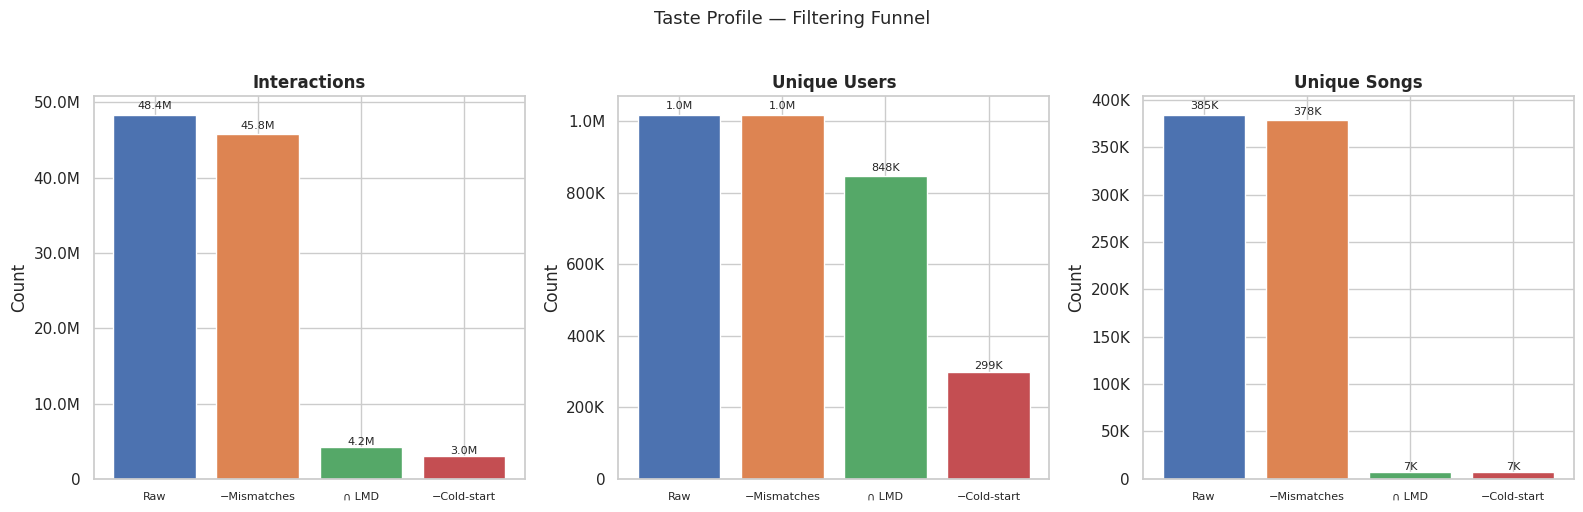

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

def _fmt(x: float) -> str:
    if x >= 1_000_000:
        return f"{x/1e6:.1f}M"
    if x >= 1_000:
        return f"{x/1e3:.0f}K"
    return str(int(x))

for ax, (col, vals) in zip(axes, [
    ("Interactions", rows_vals),
    ("Unique Users", users_vals),
    ("Unique Songs", songs_vals),
]):
    bars = ax.bar(steps, vals, color=colors, edgecolor="white")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _fmt(x)))
    ax.tick_params(axis="x", labelsize=8)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            _fmt(val),
            ha="center", va="bottom", fontsize=8,
        )

plt.suptitle("Taste Profile — Filtering Funnel", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 9 — Descriptive Analysis of Filtered Dataset

Four diagnostic plots:
1. **Play-count distribution** — log-scale histogram (heavy-tailed power law)
2. **Songs per user** — how active listeners are
3. **Users per song** — song popularity distribution
4. **Top-20 songs** — most-listened songs with play counts


In [10]:
stats_dict = build_user_song_stats(filtered, lmd_df=lmd_df)
per_user   = stats_dict["per_user"]
per_song   = stats_dict["per_song"]
pc_stats   = stats_dict["play_count"]

print("=== play_count descriptive stats ===")
print(pc_stats.to_string())
print("\n=== per-user stats (first 5 rows) ===")
print(per_user.head().to_string())
print("\n=== per-song stats (first 5 rows) ===")
print(per_song.head().to_string())


=== play_count descriptive stats ===
         play_count
count  3.048959e+06
mean   3.118003e+00
std    6.560797e+00
min    1.000000e+00
25%    1.000000e+00
50%    1.000000e+00
75%    3.000000e+00
max    3.532000e+03

=== per-user stats (first 5 rows) ===
                                          n_songs  total_plays  mean_plays  max_plays
user_id                                                                              
d8e6fa08d73821f305b9a3af1cf1e0a704473d82       24         3576  149.000000       3532
3fa44653315697f42410a30cb766a4eb102080bb       41         3206   78.195122        216
0421d096b0c80ec287d436e6f535f44b711b58ef        7         1476  210.857143        939
6ccd111af9b4baa497aacd6d1863cbf5a141acc6       34         1346   39.588235        634
c012ec364329bb08cbe3e62fe76db31f8c5d8ec3        5         1311  262.200000        683

=== per-song stats (first 5 rows) ===
                    n_users  total_plays  mean_plays  max_plays                                        

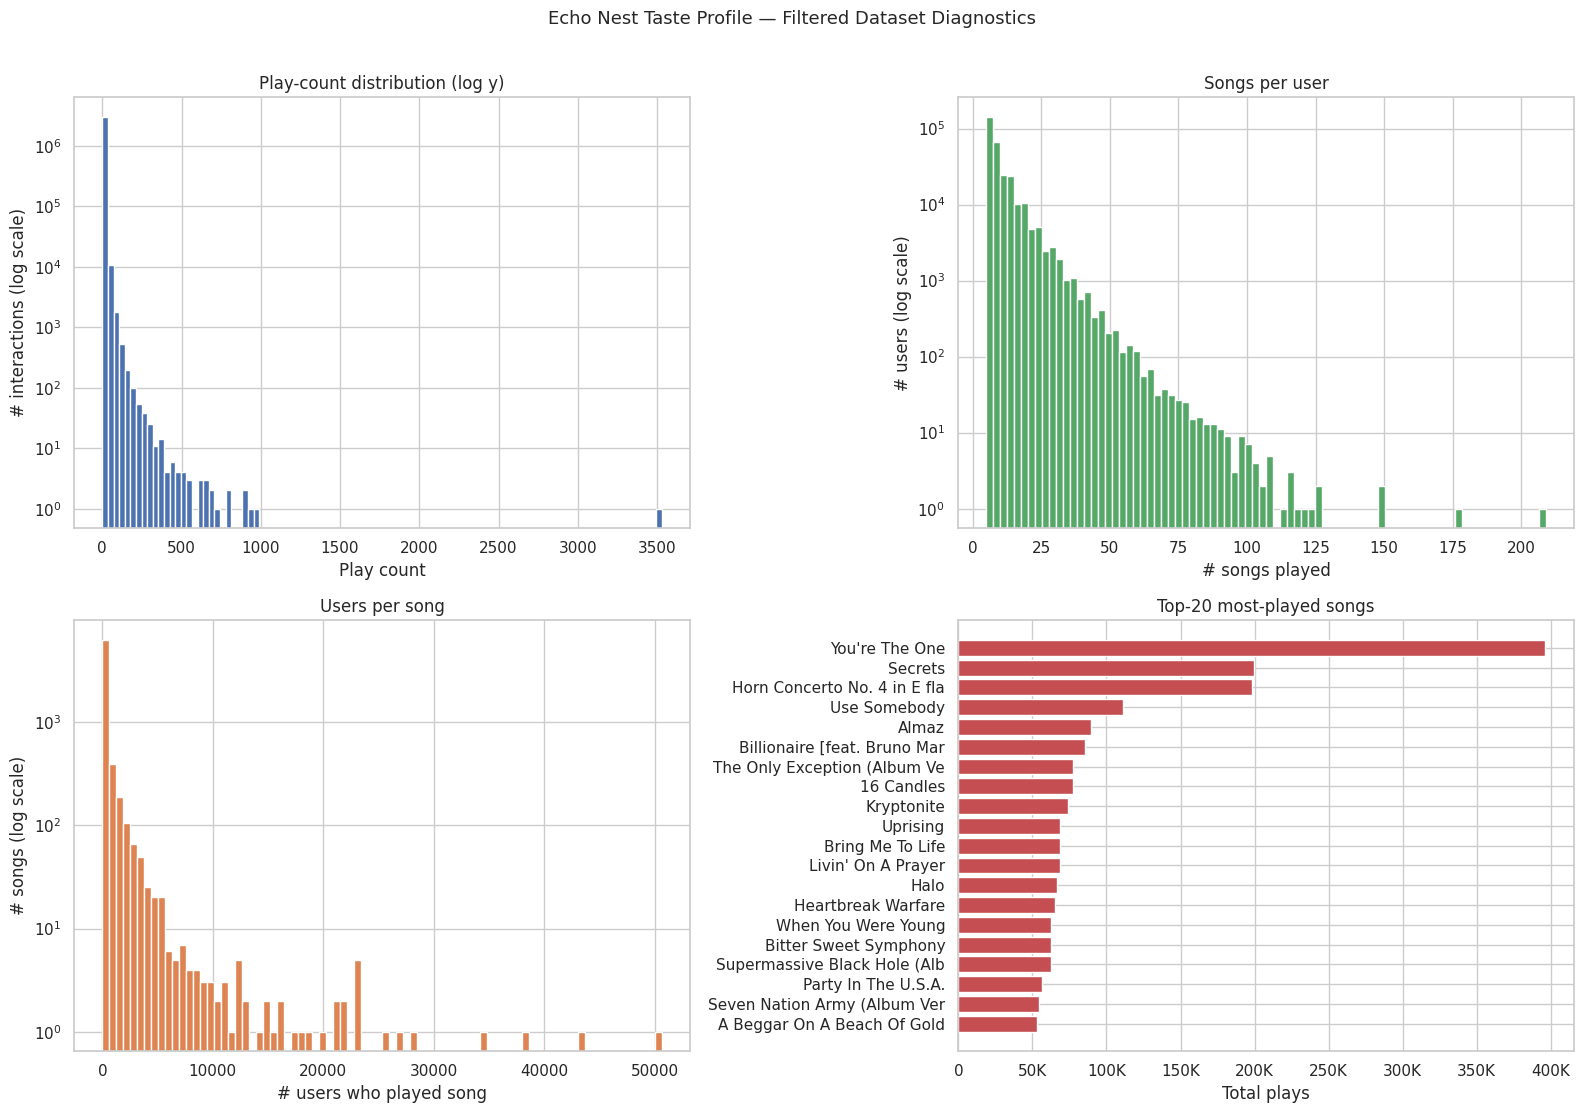

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Plot 1: play_count log-scale histogram ────────────────────────────────────
ax = axes[0, 0]
ax.hist(filtered["play_count"], bins=100, log=True, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Play count"); ax.set_ylabel("# interactions (log scale)")
ax.set_title("Play-count distribution (log y)")

# ── Plot 2: songs per user ────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(per_user["n_songs"], bins=80, log=True, color="#55A868", edgecolor="white")
ax.set_xlabel("# songs played"); ax.set_ylabel("# users (log scale)")
ax.set_title("Songs per user")

# ── Plot 3: users per song ────────────────────────────────────────────────────
ax = axes[1, 0]
ax.hist(per_song["n_users"], bins=80, log=True, color="#DD8452", edgecolor="white")
ax.set_xlabel("# users who played song"); ax.set_ylabel("# songs (log scale)")
ax.set_title("Users per song")

# ── Plot 4: top-20 most played songs ─────────────────────────────────────────
ax = axes[1, 1]
top20 = per_song.nlargest(20, "total_plays").reset_index()
label_col = "title" if "title" in top20.columns else "song_id"
labels = top20[label_col].str[:28].tolist()
ax.barh(labels[::-1], top20["total_plays"].tolist()[::-1], color="#C44E52")
ax.set_xlabel("Total plays"); ax.set_title("Top-20 most-played songs")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: _fmt(x)))

plt.suptitle("Echo Nest Taste Profile — Filtered Dataset Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 10 — Save Processed Data

Persist the filtered triplets and aggregated statistics to disk for downstream notebooks.

| File | Description |
|------|-------------|
| `filtered_triplets.parquet` | Cleaned (user, song, play_count) table |
| `per_user_stats.csv` | Per-user aggregated play statistics |
| `per_song_stats.csv` | Per-song aggregated play statistics + LMD metadata |


In [12]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

filtered.to_parquet(OUT_TRIPLETS, index=False)
per_user.reset_index().to_csv(OUT_PER_USER, index=False)
per_song.reset_index().to_csv(OUT_PER_SONG, index=False)

print("Saved files:")
for f in [OUT_TRIPLETS, OUT_PER_USER, OUT_PER_SONG]:
    size_mb = f.stat().st_size / 1e6
    print(f"  ✓  {f.name:<35}  {size_mb:6.1f} MB")

print(f"\nFiltered triplets shape : {filtered.shape}")
print(f"Unique users            : {per_user.shape[0]:,}")
print(f"Unique songs            : {per_song.shape[0]:,}")


Saved files:
  ✓  taste_profile_filtered.parquet         25.0 MB
  ✓  taste_profile_per_user.csv             17.9 MB
  ✓  taste_profile_per_song.csv              0.6 MB

Filtered triplets shape : (3048959, 3)
Unique users            : 299,156
Unique songs            : 7,227
